No handles with labels found to put in legend.


x = 0.0, y = 1.0976270078546495, residual = -0.08529417361525438
x = 0.01, y = 1.450378732744839, residual = 0.2521230242159973
x = 0.02, y = 1.2455267521432878, residual = 0.03193651655550833
x = 0.03, y = 1.1497663659937938, residual = -0.07915839665292346
x = 0.04, y = 0.9273095986778095, residual = -0.31694969102784554
x = 0.05, y = 1.3917882261333123, residual = 0.1321944093687195
x = 0.06, y = 0.9951744225253851, residual = -0.27975392129814525
x = 0.07, y = 1.9235460015641597, residual = 0.6332831306816915
x = 0.08, y = 2.0873255210020583, residual = 0.7817281230606523
x = 0.09, y = 0.9468830376515553, residual = -0.3740488873487884
x = 0.1, y = 1.7834500761653291, residual = 0.4471836241060476
x = 0.11, y = 1.277789839505809, residual = -0.07381113961241037
x = 0.12, y = 1.3760891221878646, residual = 0.009153616010707522
x = 0.13, y = 2.111193276585322, residual = 0.728923243349227
x = 0.14, y = 0.4220721163957739, residual = -0.9755324438992587
x = 0.15, y = 0.474258599403081

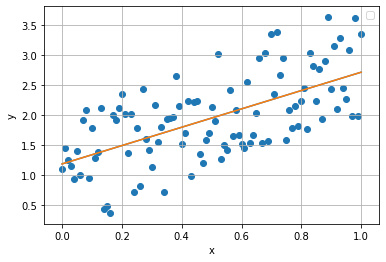

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

x = np.arange(0, 1.01, 0.01)   
x = np.sort(x)                 

noise = np.random.uniform(-1, 1, len(x))
y = 2 * x + 1 + noise

def least_squares(x, y):
    n = len(x)

    m = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - (np.sum(x))**2)
    c = (np.sum(y) - m * np.sum(x)) / n

    return m, c

Make x and y and custom least squares function

In [ ]:
m_leastsquares, c_leastsquares = least_squares(x, y)

y_leastsquares = m_leastsquares * x + c_leastsquares

A = np.vstack([x, np.ones(len(x))]).T
m_leastsquares_np, c_leastsquares_np = np.linalg.lstsq(A, y, rcond=None)[0]
y_leastsquares_np = m_leastsquares_np * x + c_leastsquares_np

residuals = y - y_leastsquares

largest_res = np.argmax(np.abs(residuals))
smallest_res = np.argmin(np.abs(residuals))

compute least squares function for numpy and custom one as well as residuals

In [ ]:
for i in range(len(x)):
    print(f"x = {x[i]}, y = {y[i]}, residual = {residuals[i]}")
    
print("\nPoint with largest residual:")
print(f"x = {x[largest_res]}, y = {y[largest_res]}")

print("\nPoint with smallest residual:")
print(f"x = {x[smallest_res]}, y = {y[smallest_res]}")

plt.figure()
plt.scatter(x, y)
plt.plot(x, y_leastsquares)
plt.plot(x, y_leastsquares_np)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

print all residuals as well as point with largest and smallest residual. Plots custom lstsq, np lstsq, and data set

The results of my function are the same as the numpy function as seen in how they overlap on the graph. 